In [3]:
#import Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [4]:

# Load dataset
df = pd.read_csv('customer_churn_dataset-testing-master.csv')


In [5]:
# DISPLAY DATA

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:\n")
print(df.info())

print("\nColumn Names:\n")
print(df.columns)



First 5 Rows:

   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                18      0  
4               

In [6]:
#check the missing value

print("\nMissing Values:\n")
print(df.isnull().sum())



Missing Values:

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


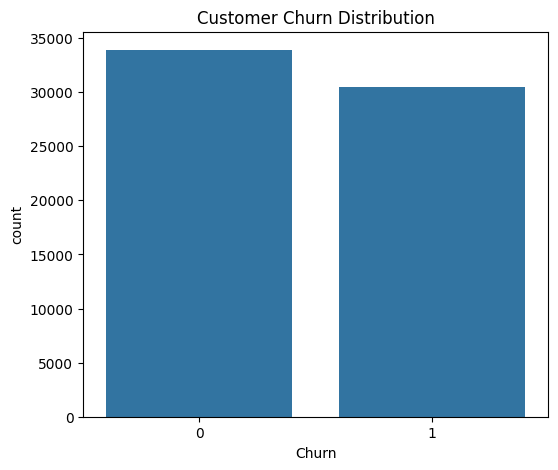

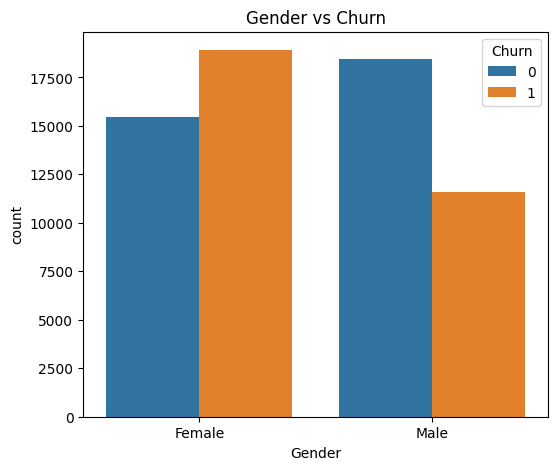

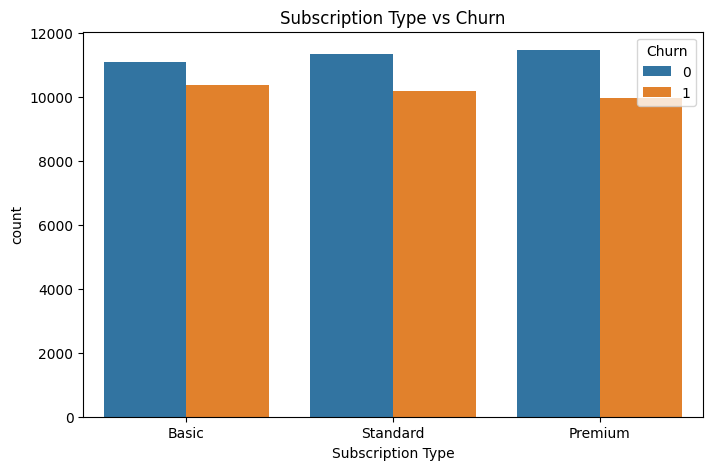

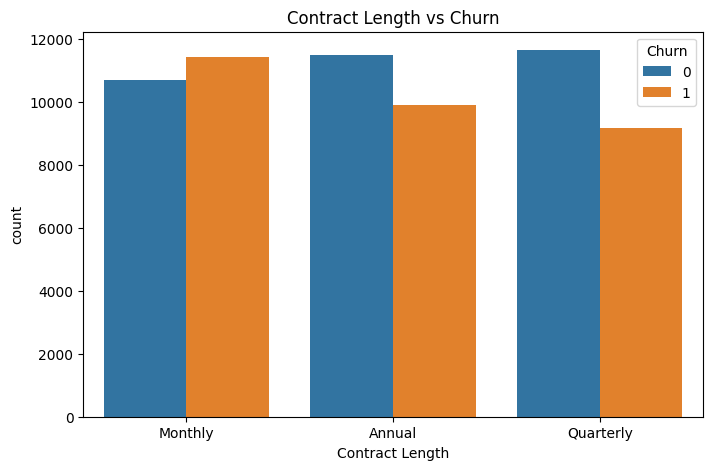

In [7]:
#EDA

# Churn Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()


# Gender vs Churn
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', hue='Churn', data=df)
plt.title('Gender vs Churn')
plt.show()


# Subscription Type vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Subscription Type', hue='Churn', data=df)
plt.title('Subscription Type vs Churn')
plt.show()


# Contract Length vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Contract Length', hue='Churn', data=df)
plt.title('Contract Length vs Churn')
plt.show()


In [8]:

# CATEGORICAL DATA

label_encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])


In [9]:
# Display the correlation of all features with 'Churn'
correlation_with_churn = df.corr()['Churn'].sort_values(ascending=False)
print("Correlation of Features with Churn:\n", correlation_with_churn)

Correlation of Features with Churn:
 Churn                1.000000
Payment Delay        0.557386
CustomerID           0.529832
Support Calls        0.304631
Tenure               0.195327
Age                  0.063457
Last Interaction    -0.002818
Subscription Type   -0.007738
Contract Length     -0.017098
Total Spend         -0.078867
Usage Frequency     -0.115098
Gender              -0.164549
Name: Churn, dtype: float64


In [10]:
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

X = df.drop('Churn', axis=1)
y = df['Churn']

In [11]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# FEATURE SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
# LOGISTIC REGRESSION MODEL

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("LOGISTIC REGRESSION RESULTS\n")

print("Accuracy:", accuracy_score(y_test, log_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))


LOGISTIC REGRESSION RESULTS

Accuracy: 0.8306019417475728

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6793
           1       0.81      0.83      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



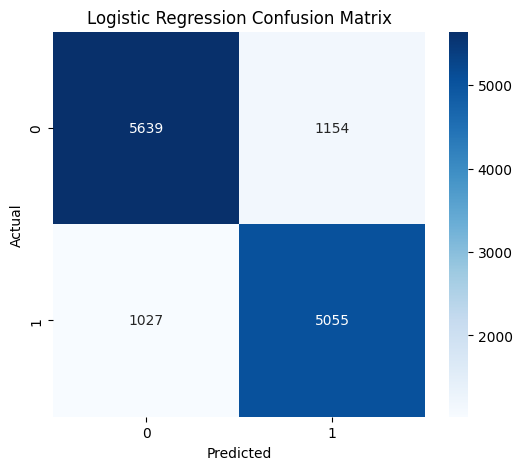

In [13]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [14]:
# DECISION TREE

tree_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("DECISION TREE RESULTS")

print("Accuracy:", accuracy_score(y_test, tree_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, tree_pred))

DECISION TREE RESULTS
Accuracy: 0.9597669902912621

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      6793
           1       0.93      0.98      0.96      6082

    accuracy                           0.96     12875
   macro avg       0.96      0.96      0.96     12875
weighted avg       0.96      0.96      0.96     12875



RANDOM FOREST RESULTS

Accuracy: 0.9994563106796116

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



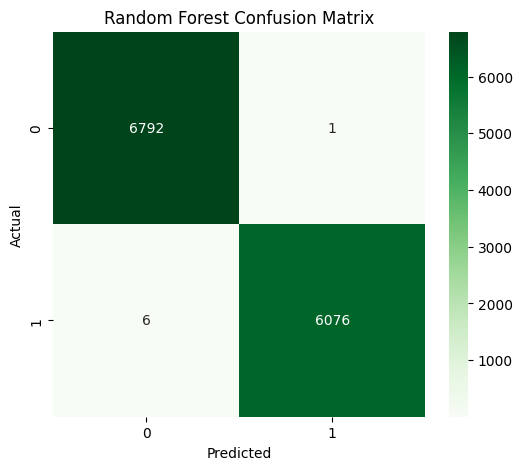

In [15]:
# RANDOM FOREST CLASSIFIER

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS\n")

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))


# RANDOM FOREST CONFUSION MATRIX

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Feature Importance:

             Feature  Importance
5      Payment Delay    0.436948
4      Support Calls    0.156691
2             Tenure    0.110662
3    Usage Frequency    0.088038
1             Gender    0.075394
7    Contract Length    0.041771
8        Total Spend    0.041748
0                Age    0.038913
9   Last Interaction    0.006685
6  Subscription Type    0.003150


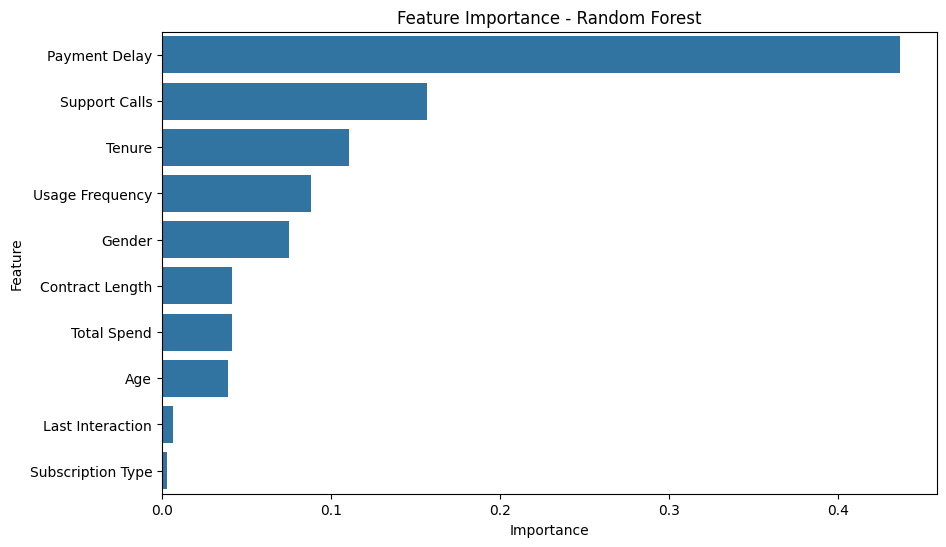

In [16]:
# FEATURE IMPORTANCE

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")
print(feature_importance)


# FEATURE IMPORTANCE GRAPH

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance - Random Forest')
plt.show()





In [17]:
# SAMPLE PREDICTION

sample_prediction = rf_model.predict(X_test[:5])

print("\nSample Predictions:")
print(sample_prediction)

print("\nActual Values:")
print(y_test.iloc[:5].values)


Sample Predictions:
[0 0 1 0 0]

Actual Values:
[0 0 1 0 0]


In [18]:
# MODEL COMPARISON

log_acc = accuracy_score(y_test, log_pred)
tree_acc = accuracy_score(y_test, tree_pred)
rf_acc = accuracy_score(y_test, rf_pred)

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [log_acc, tree_acc, rf_acc]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print("\nModel Comparison:\n")
print(comparison_df)


Model Comparison:

                 Model  Accuracy
0  Logistic Regression  0.830602
1        Decision Tree  0.959767
2        Random Forest  0.999456


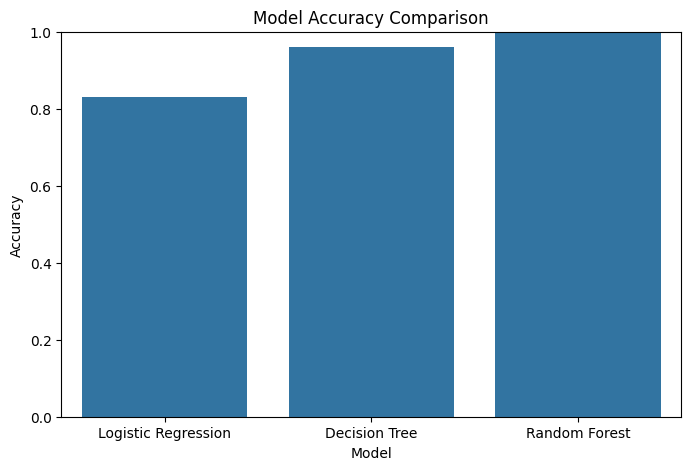

In [19]:
# ACCURACY VISUALIZATION

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title('Model Accuracy Comparison')
plt.ylim(0,1)
plt.show()

In [20]:
# XGBOOST CLASSIFIER

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBOOST RESULTS")

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("Classification Report:")
print(classification_report(y_test, xgb_pred))

XGBOOST RESULTS
Accuracy: 0.9996893203883496
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



AUC Score: 0.9999994069954112


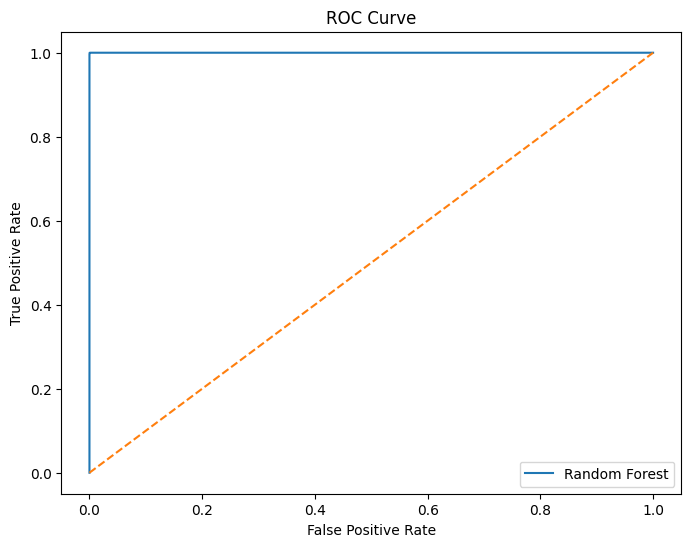

In [21]:
# ROC CURVE AND AUC SCORE

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

auc_score = roc_auc_score(y_test, rf_prob)

print("AUC Score:", auc_score)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [22]:
# FEATURE ENGINEERING


df['AvgSpendPerMonth'] = df['Total Spend'] / (df['Tenure'] + 1)

df['EngagementScore'] = (
    df['Usage Frequency'] / (df['Support Calls'] + 1)
)


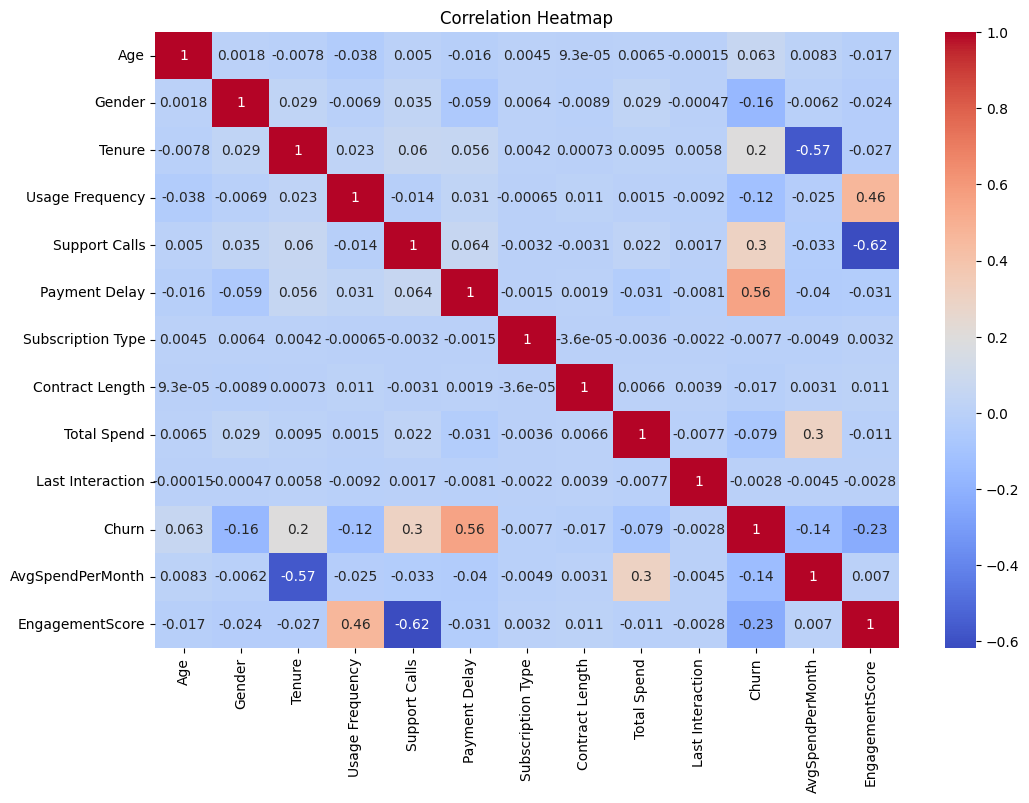

In [23]:
# CORRELATION HEATMAP

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

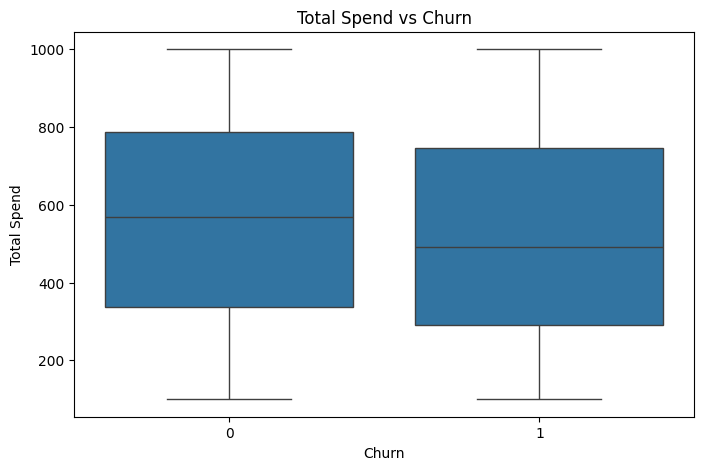

In [24]:

# BOXPLOT ANALYSIS

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Total Spend',
    data=df
)

plt.title('Total Spend vs Churn')
plt.show()

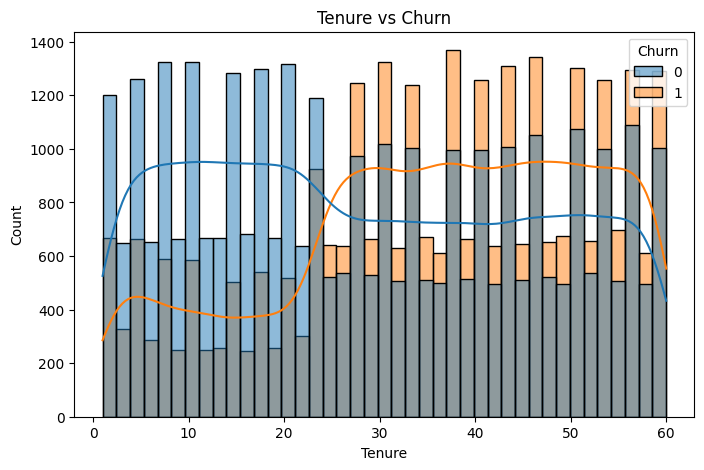

In [25]:
# TENURE VS CHURN ANALYSIS

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Tenure',
    hue='Churn',
    kde=True
)

plt.title('Tenure vs Churn')
plt.show()

In [26]:
# CHI-SQUARE TEST

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df['Subscription Type'],
    df['Churn']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test")
print("P-value:", p)

if p < 0.05:
    print("Subscription Type significantly affects churn")
else:
    print("No significant relationship")

Chi-Square Test
P-value: 0.0010830523222382482
Subscription Type significantly affects churn


In [27]:
# T-TEST

from scipy.stats import ttest_ind

churned = df[df['Churn']==1]['Total Spend']
not_churned = df[df['Churn']==0]['Total Spend']

stat, p_value = ttest_ind(churned, not_churned)

print("T-Test Results")
print("P-value:", p_value)

if p_value < 0.05:
    print("Average spend differs significantly")
else:
    print("No significant difference")

T-Test Results
P-value: 2.4142796591781348e-89
Average spend differs significantly


In [28]:
# SMOTE FOR IMBALANCED DATA

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:")
print(pd.Series(y_resampled).value_counts())

After SMOTE:
Churn
1    33881
0    33881
Name: count, dtype: int64


In [29]:
# HYPERPARAMETER TUNING

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50,100],
    'max_depth': [3,5,7]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 7, 'n_estimators': 100}
Best Accuracy:
0.9864269129828909


In [30]:
# CUSTOMER SEGMENTATION USING KMEANS

from sklearn.cluster import KMeans

kmeans_features = df[[
    'Age',
    'Total Spend',
    'Tenure'
]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(kmeans_features)

df['CustomerSegment'] = clusters



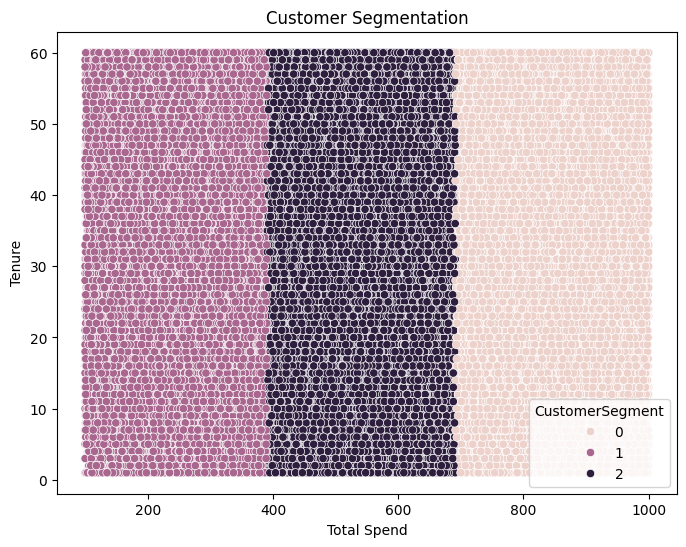

In [31]:
# CUSTOMER SEGMENT VISUALIZATION

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Total Spend',
    y='Tenure',
    hue='CustomerSegment',
    data=df
)

plt.title('Customer Segmentation')
plt.show()

In [32]:

print("BUSINESS INSIGHTS\n")

print("1. Customers with more support calls are more likely to churn")
print("2. Long contract customers have lower churn")
print("3. High spending customers are easier to retain")
print("4. Subscription type strongly affects customer retention")
print("5. Customers with low engagement are high churn risks")


print("\n\nBUSINESS RECOMMENDATIONS\n")

print("1. Improve customer support response quality")
print("2. Offer loyalty rewards for long-term customers")
print("3. Provide discounts for high-risk churn users")
print("4. Target low-engagement customers with marketing campaigns")
print("5. Introduce personalized subscription plans")


BUSINESS INSIGHTS

1. Customers with more support calls are more likely to churn
2. Long contract customers have lower churn
3. High spending customers are easier to retain
4. Subscription type strongly affects customer retention
5. Customers with low engagement are high churn risks


BUSINESS RECOMMENDATIONS

1. Improve customer support response quality
2. Offer loyalty rewards for long-term customers
3. Provide discounts for high-risk churn users
4. Target low-engagement customers with marketing campaigns
5. Introduce personalized subscription plans


In [33]:
# SAVE MODEL

import joblib

joblib.dump(rf_model, 'customer_churn_model.pkl')

print("Model Saved Successfully")


Model Saved Successfully
